## **4주차 과제**

1. 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요.
2. 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요.
3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.
4.  가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요.

5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.
6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.
7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.

### **1. 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요.**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.random.rand(1000, 4)
Y = np.random.randint(0, 2, size=1000)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.4, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size = 0.5, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)
print(Y_train.shape, Y_val.shape, Y_test.shape)

(600, 4) (200, 4) (200, 4)
(600,) (200,) (200,)


### **2. 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요.**

In [ ]:
np.random.seed(42)
X = np.random.rand(1000, 5)
Y = np.random.randint(0, 2, size=1000)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# K-NN 모델
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)
# K-NN 모델 학습
knn_model.fit(X_train, Y_train)

KNeighborsClassifier()

In [ ]:
accuracy = knn_model.score(X_test, Y_test)
print(f"정확도:{accuracy:.4f}")
sample = X_test[0].reshape(1,-1)
pred = knn_model.predict(sample)
predicted_class = pred[0]
print(f"예측된 클래스: {predicted_class}")

정확도:0.5000
예측된 클래스: 1


### **3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as opt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

X = np.random.seed(42)
X = np.random.rand(1000, 5)
y = np.random.randint(0, 2, size=1000)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PyTorch Tensor 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Perceptron

perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
print("perceptron Accuracy: ",accuracy_score(y_test,y_pred))
print("classification_report",classification_report(y_test,y_pred))

perceptron Accuracy:  0.565
classification_report               precision    recall  f1-score   support

           0       0.58      0.45      0.51        99
           1       0.56      0.67      0.61       101

    accuracy                           0.56       200
   macro avg       0.57      0.56      0.56       200
weighted avg       0.57      0.56      0.56       200



In [ ]:
# SVM
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())
y_pred_svm = svm_model.predict(X_test_tensor.numpy())
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.505
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        99
           1       0.51      1.00      0.67       101

    accuracy                           0.51       200
   macro avg       0.25      0.50      0.34       200
weighted avg       0.26      0.51      0.34       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Random Forest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

rf_model1 = RandomForestClassifier(n_estimators=100,  random_state=42)
rf_model1.fit(X_train, y_train)
rf_model2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model2.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [ ]:
acc1 = rf_model1.score(X_test, y_test)
acc2 = rf_model2.score(X_test, y_test)
print(f"Accuracy 1:{acc1:.4f}")
print(f"Accuracy 2:{acc2:.4f}")

Accuracy 1:0.4650
Accuracy 2:0.5000


In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())

accuracy = nb_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
print(f"Accuracy :{accuracy:.4f}")

Accuracy :0.5000


### **4. 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요.**

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

N = 2000
x_small, y_small = x_train[:N], y_train[:N]

def create_model():
  model = Sequential([
      Input(shape=(28, 28, 1)),
      Conv2D(32, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),
      Conv2D(64, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),
      Flatten(),
      Dense(64, activation='relu'),
      Dense(10, activation='softmax')
  ])
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

EPOCHS = 20

# 증강 없이 학습
without_model = create_model()
hist_without = without_model.fit(x_small, y_small, epochs=EPOCHS, batch_size=32, validation_data=(x_test, y_test), verbose=0)

# 증강 적용
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode = 'nearest')
model_with = create_model()
hist_with = model_with.fit(datagen.flow(x_small, y_small, batch_size=32), epochs=EPOCHS, steps_per_epoch=len(x_small) // 32, validation_data=(x_test, y_test), verbose=0)

print(f"\n최종 정확도 - 증강 미적용: {hist_without.history['val_accuracy'][-1]:.4f}")
print(f"최종 정확도 - 증강 적용  : {hist_with.history['val_accuracy'][-1]:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



최종 정확도 - 증강 미적용: 0.9628
최종 정확도 - 증강 적용  : 0.9579


### **5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.**

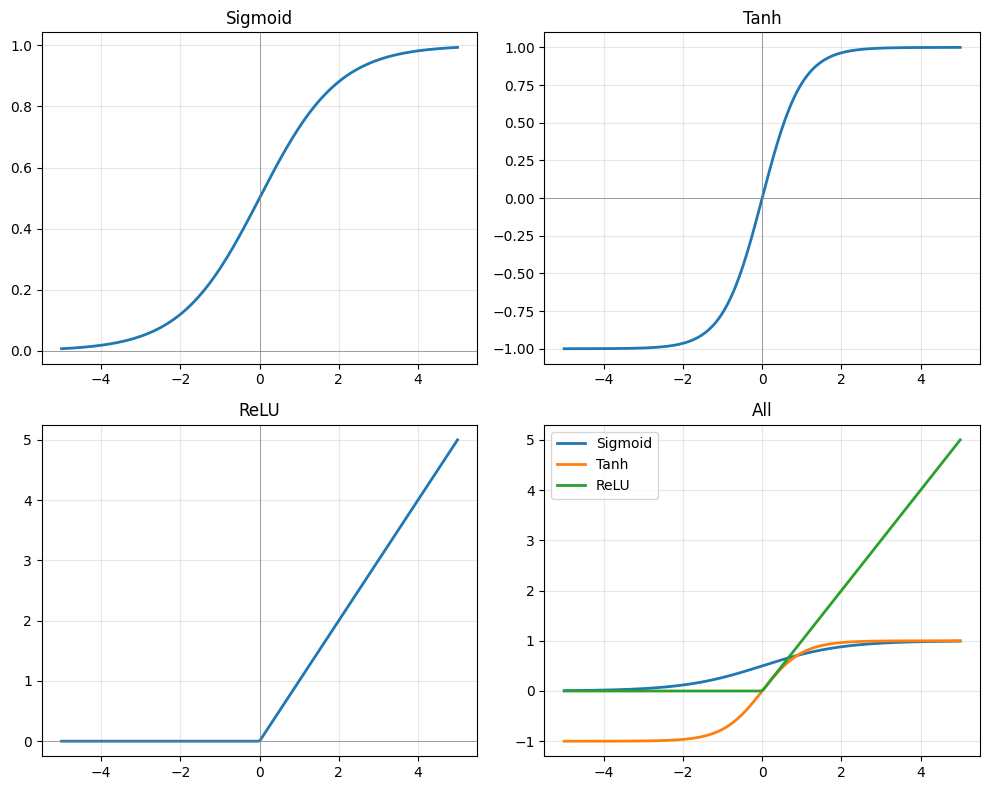

In [ ]:
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def tanh(x):
    return np.tanh(x)
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 200)
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

results = {
    'Sigmoid': y_sigmoid,
    'Tanh': y_tanh,
    'ReLU': y_relu,
}
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()   # 2x2 → 1차원 4개로 펴기

# for문으로 앞 3칸에 함수 하나씩
for ax, (name, y) in zip(axes, results.items()):
    ax.plot(x, y, linewidth=2)
    ax.set_title(name)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.3)

# 4번째 칸: 세 함수 한 번에
for name, y in results.items():
    axes[3].plot(x, y, label=name, linewidth=2)
axes[3].set_title('All')
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.**

In [ ]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y  = make_circles(n_samples=1000, noise=0.1, factor=0.2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.float32).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=32, shuffle=False)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

mlp_model     = MLP()
mlp_criterion = nn.BCELoss()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01)

mlp_epochs = 100
for epoch in range(mlp_epochs):
    mlp_model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        mlp_optimizer.zero_grad()
        outputs = mlp_model(X_batch)
        loss = mlp_criterion(outputs, y_batch)
        loss.backward()
        mlp_optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{mlp_epochs}, Loss: {epoch_loss / len(train_loader):.4f}')

mlp_model.eval()
correct = 0
total   = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs   = mlp_model(X_batch)
        predicted = (outputs >= 0.5).float()
        total   += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

mlp_accuracy = correct / total
print(f'MLP Test Accuracy: {mlp_accuracy * 100:.2f}%')

Epoch 20/100, Loss: 0.0000
Epoch 40/100, Loss: 0.0000
Epoch 60/100, Loss: 0.0000
Epoch 80/100, Loss: 0.0000
Epoch 100/100, Loss: 0.0000
MLP Test Accuracy: 100.00%


### **7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([transforms.Resize(32),
                                transforms.ToTensor()])

# MNIST 데이터셋 다운로드
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

num_classes = 10

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


In [ ]:
# CNN 모델 생성
class simpleCNN(nn.Module):
  def __init__(self):
    super(simpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(128 * 4 * 4, 256)
    self.fc2 = nn.Linear(256, num_classes)

  def forward(self, x):
    x = torch.relu(self.conv1(x))
    x = self.pool(x)
    x = torch.relu(self.conv2(x))
    x = self.pool(x)
    x = torch.relu(self.conv3(x))
    x = self.pool(x)
    x = self.flatten(x)
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

model = simpleCNN()

# 손실함수/최적화
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

Epoch 1, Loss: 0.1682781601214964
Epoch 2, Loss: 0.04722792841345151
Epoch 3, Loss: 0.03136270812737804
Epoch 4, Loss: 0.025384907297863774
Epoch 5, Loss: 0.02005395712145548
Epoch 6, Loss: 0.015541264534980993
Epoch 7, Loss: 0.013909115845632257
Epoch 8, Loss: 0.012385365101712724
Epoch 9, Loss: 0.009825429312750076
Epoch 10, Loss: 0.008574986036608962


In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 99.06%
